In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,apna enclave,sector 3,0.50,7692.0,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,tulsiani easy in homes,sohna road,0.40,6723.0,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,East,661.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,smart world orchard,sector 61,1.47,12250.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,East,1333.0,1,0,0,0,0,Relatively New,Unfurnished,49,4.20
4,flat,parkwood westend,sector 92,0.70,5204.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,East,1217.0,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [5]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [6]:
train_df.head()

,property_type,sector,price,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating
0,flat,sector 7,0.45,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00
1,flat,sector 3,0.50,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25
2,flat,sohna road,0.40,Carpet area: 595 (55.28 sq.m.),2,2,3,12.0,East,661.0,0,0,0,0,0,New Property,Unfurnished,31,4.25
3,flat,sector 61,1.47,Carpet area: 1200 (111.48 sq.m.),2,2,2,2.0,East,1333.0,1,0,0,0,0,Relatively New,Unfurnished,49,4.20
4,flat,sector 92,0.70,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,East,1217.0,1,0,0,0,0,Under Construction,Unfurnished,0,4.00


In [7]:
train_df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price              1.000000
built_up_area      0.724482
bathroom           0.610240
bedRoom            0.572662
servant room       0.395196
pooja room         0.323536
store room         0.307230
combined_rating    0.271825
study room         0.246184
luxury_score       0.073795
others            -0.016226
floorNum          -0.090450
Name: price, dtype: float64

In [8]:
# converting floornum and luxury score into categorical column

<Axes: ylabel='luxury_score'>

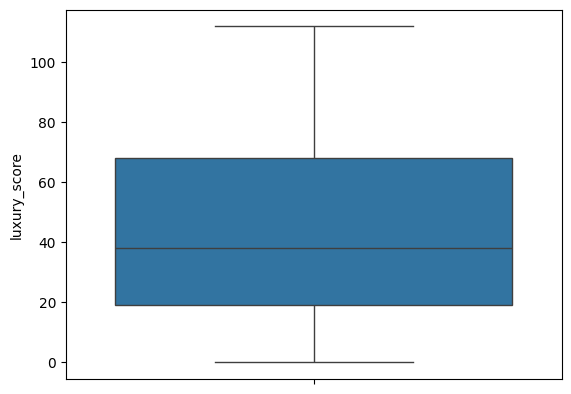

In [9]:
sns.boxplot(df['luxury_score'])

In [10]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [11]:
train_df['luxury_category']=train_df['luxury_score'].apply(categorize_luxury)

In [12]:
train_df.head(2)

,property_type,sector,price,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,luxury_category
0,flat,sector 7,0.45,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00,Low
1,flat,sector 3,0.50,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25,Low


<Axes: ylabel='floorNum'>

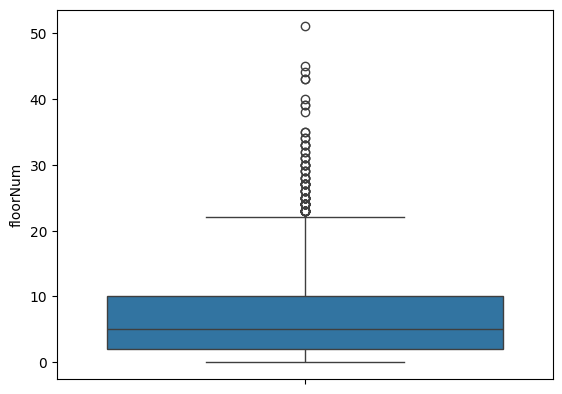

In [13]:
sns.boxplot(df['floorNum'])

In [14]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [15]:
train_df['floor_category']=train_df['floorNum'].apply(categorize_floor)

In [16]:
train_df.head(2)

,property_type,sector,price,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,luxury_score,combined_rating,luxury_category,floor_category
0,flat,sector 7,0.45,Carpet area: 900 (83.61 sq.m.),2,2,1,4.0,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,11,4.00,Low,Mid Floor
1,flat,sector 3,0.50,Carpet area: 650 (60.39 sq.m.),2,2,1,1.0,West,722.0,0,0,0,0,0,Old Property,Furnished,14,4.25,Low,Low Floor


In [17]:
train_df.drop(columns=['luxury_score','floorNum'],inplace=True)

In [18]:
train_df.sample(5)

,property_type,sector,price,areaWithType,bedRoom,bathroom,balcony,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,combined_rating,luxury_category,floor_category
2814,house,sector 43,1.950,Plot area 215(179.77 sq.m.),3,4,3+,West,1935.0,0,1,0,0,0,New Property,Furnished,5.00,Low,Mid Floor
3090,house,sector 15,1.800,Plot area 200(167.23 sq.m.),4,3,1,North-East,1800.0,0,0,0,0,0,Old Property,Unfurnished,4.12,Low,Low Floor
3394,house,sector 82,1.600,Plot area 2425(225.29 sq.m.),4,4,3+,North,2425.0,0,1,0,0,0,Moderately Old,Unfurnished,4.00,Medium,High Floor
2338,flat,sector 5,0.255,Carpet area: 583 (54.16 sq.m.),1,1,1,North-East,648.0,0,0,0,0,0,Relatively New,Unfurnished,4.25,Low,Mid Floor
3417,house,sector 55,1.640,Plot area 180(150.5 sq.m.),3,3,2,South,1620.0,1,1,0,0,0,New Property,Furnished,4.25,Low,Mid Floor


In [19]:
df.shape

(3573, 21)

In [20]:
train_df.drop(columns=['areaWithType'],inplace=True)

In [21]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,combined_rating,luxury_category,floor_category
0,flat,sector 7,0.45,2,2,1,West,1000.0,0,0,0,0,0,Relatively New,Unfurnished,4.00,Low,Mid Floor
1,flat,sector 3,0.50,2,2,1,West,722.0,0,0,0,0,0,Old Property,Furnished,4.25,Low,Low Floor
2,flat,sohna road,0.40,2,2,3,East,661.0,0,0,0,0,0,New Property,Unfurnished,4.25,Low,High Floor
3,flat,sector 61,1.47,2,2,2,East,1333.0,1,0,0,0,0,Relatively New,Unfurnished,4.20,Low,Low Floor
4,flat,sector 92,0.70,2,2,3,East,1217.0,1,0,0,0,0,Under Construction,Unfurnished,4.00,Low,Mid Floor


In [24]:
train_df.drop(columns=['study room','store room','pooja room','others'],inplace=True)

In [26]:
train_df.to_csv('gurgaon_properties_post_feature_selection_v2.csv',index=False)

In [22]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 37', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13440\848989002.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_df.select_dtypes(include=['object']).columns


In [23]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,combined_rating,luxury_category,floor_category
0,0.0,72.0,2,2,1.0,7.0,1000.0,0,0,0,0,0,3.0,2.0,4.00,0.0,2.0
1,0.0,32.0,2,2,1.0,7.0,722.0,0,0,0,0,0,2.0,0.0,4.25,0.0,1.0
2,0.0,100.0,2,2,3.0,0.0,661.0,0,0,0,0,0,1.0,2.0,4.25,0.0,0.0
3,0.0,64.0,2,2,2.0,0.0,1333.0,1,0,0,0,0,3.0,2.0,4.20,0.0,1.0
4,0.0,96.0,2,2,3.0,0.0,1217.0,1,0,0,0,0,4.0,2.0,4.00,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,1.0,59.0,3,3,3.0,3.0,1700.0,0,0,1,0,0,0.0,0.0,4.00,1.0,1.0
3569,1.0,29.0,4,4,3.0,2.0,1800.0,1,1,0,1,0,0.0,2.0,5.00,0.0,1.0
3570,1.0,28.0,3,2,3.0,1.0,1350.0,1,0,0,0,0,2.0,2.0,5.00,0.0,1.0
3571,1.0,29.0,3,3,2.0,0.0,1350.0,1,1,0,0,0,0.0,2.0,5.00,0.0,1.0


In [24]:
y_label

0       0.45
1       0.50
2       0.40
3       1.47
4       0.70
        ... 
3568    4.75
3569    5.50
3570    4.25
3571    4.50
3572    3.25
Name: price, Length: 3573, dtype: float64

Technique 1 - Correlation Analysis

<Axes: >

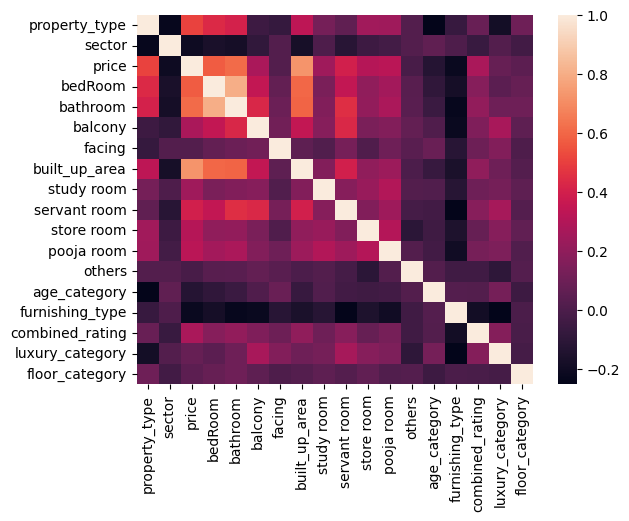

In [25]:
sns.heatmap(data_label_encoded.corr())

In [26]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.202913
1,price,1.000000
2,bedRoom,0.572662
3,bathroom,0.610240
4,balcony,0.274313
5,facing,0.021542
6,built_up_area,0.724482
7,study room,0.246184
8,servant room,0.395196
9,store room,0.307230


Technique 2 - Random Forest Feature Importance

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.625254
0,property_type,0.095883
1,sector,0.079379
14,combined_rating,0.053084
8,servant room,0.031303
2,bedRoom,0.022359
3,bathroom,0.022349
5,facing,0.017159
12,age_category,0.013496
4,balcony,0.009928


Technique 3 - Gradient Boosting Feature importances

In [28]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.654272
1,sector,0.084927
0,property_type,0.078616
14,combined_rating,0.048704
3,bathroom,0.044123
8,servant room,0.037499
2,bedRoom,0.030152
5,facing,0.005563
12,age_category,0.004290
7,study room,0.002971


Technique 4 - Permutation Importance

In [29]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.717205
0,property_type,0.139634
1,sector,0.122616
14,combined_rating,0.061797
8,servant room,0.044507
3,bathroom,0.009077
4,balcony,0.002705
15,luxury_category,0.002124
5,facing,0.001701
16,floor_category,0.001359


Technique 5 - LASSO

In [30]:
# although not very reliable because i have applied ordinalencoder for applying linear models need to apply one hot encoding
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.348196
0,property_type,0.640843
3,bathroom,0.418082
14,combined_rating,0.256622
8,servant room,0.212574
9,store room,0.203845
7,study room,0.181771
10,pooja room,0.111313
15,luxury_category,-0.007365
16,floor_category,-0.014881


Technique 6 - RFE

In [31]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.626228
0,property_type,0.091223
1,sector,0.079516
14,combined_rating,0.058300
8,servant room,0.028135
3,bathroom,0.024291
2,bedRoom,0.022402
5,facing,0.015623
12,age_category,0.014766
4,balcony,0.009430


Technique 7 - Linear Regression Weights

In [32]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.362899
0,property_type,0.639165
3,bathroom,0.466381
14,combined_rating,0.264673
8,servant room,0.220783
9,store room,0.211073
7,study room,0.189890
10,pooja room,0.116778
15,luxury_category,-0.024066
16,floor_category,-0.026264


Technique 8 - SHAP

In [33]:
!pip install shap


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.244212
0,property_type,0.457763
1,sector,0.304612
14,combined_rating,0.185600
8,servant room,0.140729
3,bathroom,0.085296
2,bedRoom,0.045267
4,balcony,0.032799
12,age_category,0.030242
13,furnishing_type,0.020848


In [ ]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df6,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [ ]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,rfe_score,SHAP_score
feature,,,,,,
sector,-0.202913,0.079379,0.084952,0.122616,0.081805,0.304612
bedRoom,0.572662,0.022359,0.030191,-0.003948,0.021962,0.045267
bathroom,0.610240,0.022349,0.043961,0.009077,0.023183,0.085296
balcony,0.274313,0.009928,0.001791,0.002705,0.010068,0.032799
facing,0.021542,0.017159,0.005562,0.001701,0.014849,0.020120
built_up_area,0.724482,0.625254,0.654252,0.717205,0.625225,1.244212
study room,0.246184,0.004672,0.003009,-0.000146,0.006518,0.009167
servant room,0.395196,0.031303,0.037499,0.044507,0.030407,0.140729
store room,0.307230,0.003034,0.001129,-0.006158,0.003569,0.006059


In [ ]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [ ]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.683622
sector             0.107896
combined_rating    0.064603
servant room       0.044099
bathroom           0.029365
bedRoom            0.019679
facing             0.010486
age_category       0.009659
balcony            0.008395
furnishing_type    0.005155
floor_category     0.004757
study room         0.003937
pooja room         0.003112
luxury_category    0.002706
others             0.001565
store room         0.000965
dtype: float64

In [ ]:
# to drop pooja room, study room, others, store room
X_label

,property_type,sector,bedRoom,bathroom,balcony,facing,built_up_area,study room,servant room,store room,pooja room,others,age_category,furnishing_type,combined_rating,luxury_category,floor_category
0,0.0,72.0,2,2,1.0,7.0,1000.0,0,0,0,0,0,3.0,2.0,4.00,0.0,2.0
1,0.0,32.0,2,2,1.0,7.0,722.0,0,0,0,0,0,2.0,0.0,4.25,0.0,1.0
2,0.0,100.0,2,2,3.0,0.0,661.0,0,0,0,0,0,1.0,2.0,4.25,0.0,0.0
3,0.0,64.0,2,2,2.0,0.0,1333.0,1,0,0,0,0,3.0,2.0,4.20,0.0,1.0
4,0.0,96.0,2,2,3.0,0.0,1217.0,1,0,0,0,0,4.0,2.0,4.00,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,1.0,59.0,3,3,3.0,3.0,1700.0,0,0,1,0,0,0.0,0.0,4.00,1.0,1.0
3569,1.0,29.0,4,4,3.0,2.0,1800.0,1,1,0,1,0,0.0,2.0,5.00,0.0,1.0
3570,1.0,28.0,3,2,3.0,1.0,1350.0,1,0,0,0,0,2.0,2.0,5.00,0.0,1.0
3571,1.0,29.0,3,3,2.0,0.0,1350.0,1,1,0,0,0,0.0,2.0,5.00,0.0,1.0


In [ ]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.7522778283738208)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others','store room']), y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.7592594059023628)

In [ ]:
export_df=X_label.drop(columns=['others','study room','pooja room','store room'])
export_df['price']=y_label

In [ ]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,facing,built_up_area,servant room,age_category,furnishing_type,combined_rating,luxury_category,floor_category,price
0,0.0,72.0,2,2,1.0,7.0,1000.0,0,3.0,2.0,4.00,0.0,2.0,0.45
1,0.0,32.0,2,2,1.0,7.0,722.0,0,2.0,0.0,4.25,0.0,1.0,0.50
2,0.0,100.0,2,2,3.0,0.0,661.0,0,1.0,2.0,4.25,0.0,0.0,0.40
3,0.0,64.0,2,2,2.0,0.0,1333.0,0,3.0,2.0,4.20,0.0,1.0,1.47
4,0.0,96.0,2,2,3.0,0.0,1217.0,0,4.0,2.0,4.00,0.0,2.0,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,1.0,59.0,3,3,3.0,3.0,1700.0,0,0.0,0.0,4.00,1.0,1.0,4.75
3569,1.0,29.0,4,4,3.0,2.0,1800.0,1,0.0,2.0,5.00,0.0,1.0,5.50
3570,1.0,28.0,3,2,3.0,1.0,1350.0,0,2.0,2.0,5.00,0.0,1.0,4.25
3571,1.0,29.0,3,3,2.0,0.0,1350.0,1,0.0,2.0,5.00,0.0,1.0,4.50


In [ ]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)